In [2]:
import tensorflow as tf 
from tensorflow .keras import models, layers
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
IMAGE_SIZE= 256
Batch_Size= 32

In [5]:
dataset= tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle= True,
    image_size= (IMAGE_SIZE, IMAGE_SIZE),
    batch_size= Batch_Size
)

Found 2152 files belonging to 3 classes.


In [6]:
class_name= dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

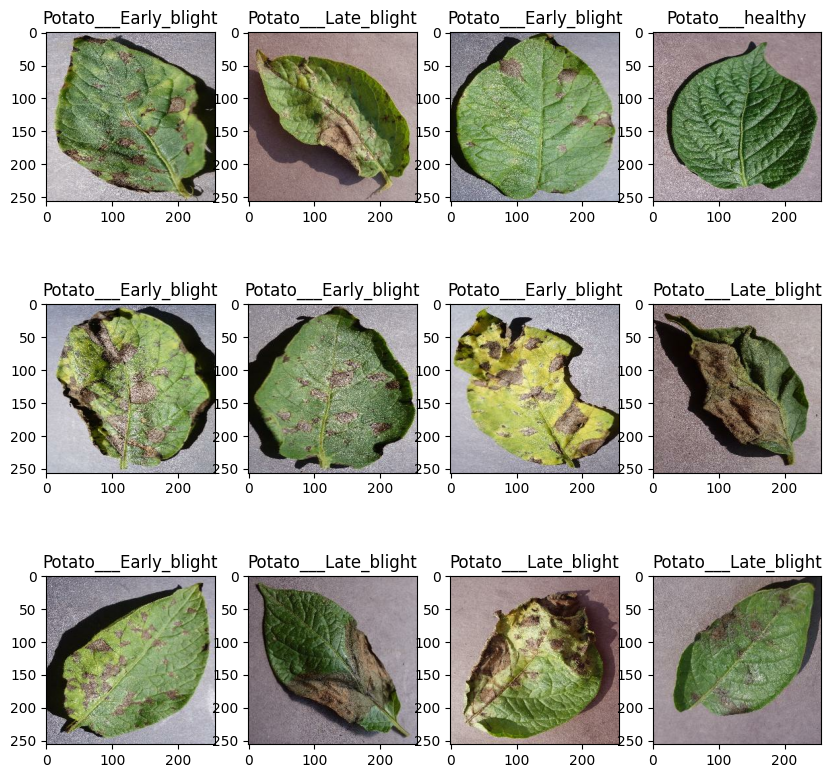

In [7]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax= plt.subplot(3,4,i+1)
        plt.title(class_name[label_batch[i]])
        plt.imshow(image_batch[i].numpy().astype('uint8'))

In [8]:
len(dataset)

68

In [9]:
train_size= 0.8
train = train_size* len(dataset)
train

54.400000000000006

In [10]:
train_ds= dataset.take(54)
test_ds= dataset.skip(54)

In [11]:
val_size= 0.1
len(dataset)*val_size

6.800000000000001

In [12]:
validation_ds= test_ds.take(6)
test_ds = test_ds.skip(6)

In [13]:
len(test_ds)

8

In [16]:
def get_dataset_partitions_tf(ds, train_split= 0.8, val_split= 0.1, shuffle= True, shuffle_size= 10000):
    ds_size= len(ds)

    if shuffle:
        ds= ds.shuffle(shuffle_size, seed= 12)

    train_size= int(train_split*ds_size)
    train_ds= ds.take(train_size)

    val_size= int(ds_size*val_split)
    val_ds= ds.skip(train_size).take(val_size)
    test_ds= ds.skip(train_size).skip(val_size)

    return train_ds , val_ds, test_ds


In [17]:
train_ds , val_ds, test_ds= get_dataset_partitions_tf(dataset)

In [20]:
len(test_ds)

8

In [23]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)
val_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)
test_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)

In [24]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1/255)
])

In [25]:
data_augmentation= tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])